# 04 Model Training

Train the four planned baseline models plus a simple Logistic Regression + LightGBM hybrid, compare their metrics, and save report-ready result tables and figures.

In [11]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))

from evaluation import (
    blend_probabilities,
    build_precision_recall_curve_df,
    build_threshold_table,
    evaluate_predictions,
    evaluate_with_best_f1_threshold,
    find_threshold_for_target_precision,
)
from models import train_lightgbm_baseline, train_mlp_baseline

In [12]:
processed_dir = PROJECT_ROOT / "data" / "processed"
tables_dir = PROJECT_ROOT / "outputs" / "tables"
figures_dir = PROJECT_ROOT / "outputs" / "figures"
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

train_linear = pd.read_parquet(processed_dir / "train_linear_ready.parquet")
train_tree = pd.read_parquet(processed_dir / "train_tree_ready.parquet")

print("Linear-ready shape:", train_linear.shape)
print("Tree-ready shape:", train_tree.shape)

Linear-ready shape: (307511, 600)
Tree-ready shape: (307511, 600)


In [13]:
X_linear = train_linear.drop(columns=["TARGET"])
y_linear = train_linear["TARGET"]

X_tree = train_tree.drop(columns=["TARGET"])
y_tree = train_tree["TARGET"]

X_train_linear, X_val_linear, y_train_linear, y_val_linear = train_test_split(
    X_linear,
    y_linear,
    test_size=0.2,
    random_state=42,
    stratify=y_linear,
)

X_train_tree, X_val_tree, y_train_tree, y_val_tree = train_test_split(
    X_tree,
    y_tree,
    test_size=0.2,
    random_state=42,
    stratify=y_tree,
)

print("Linear train shape:", X_train_linear.shape)
print("Linear val shape:", X_val_linear.shape)
print("Tree train shape:", X_train_tree.shape)
print("Tree val shape:", X_val_tree.shape)

Linear train shape: (246008, 599)
Linear val shape: (61503, 599)
Tree train shape: (246008, 599)
Tree val shape: (61503, 599)


## Baseline Models

In [14]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
)

log_reg.fit(X_train_linear, y_train_linear)
log_reg_probs = log_reg.predict_proba(X_val_linear)[:, 1]
log_reg_results = evaluate_predictions(y_val_linear, log_reg_probs)

print("Logistic Regression Results:")
for metric, value in log_reg_results.items():
    print(f"{metric}: {value:.4f}")

Logistic Regression Results:
accuracy: 0.7110
precision: 0.1755
recall: 0.6973
f1: 0.2804
roc_auc: 0.7752
average_precision: 0.2635


In [15]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=20,
    min_samples_leaf=10,
    n_jobs=-1,
    class_weight="balanced_subsample",
    random_state=42,
)

rf.fit(X_train_tree, y_train_tree)
rf_probs = rf.predict_proba(X_val_tree)[:, 1]
rf_results = evaluate_predictions(y_val_tree, rf_probs)

print("Random Forest Results:")
for metric, value in rf_results.items():
    print(f"{metric}: {value:.4f}")

Random Forest Results:
accuracy: 0.8931
precision: 0.3069
recall: 0.2578
f1: 0.2802
roc_auc: 0.7664
average_precision: 0.2447


In [16]:
lgbm_model, lgbm_results, y_val_lgbm, lgbm_probs = train_lightgbm_baseline()

print("LightGBM Results:")
for metric, value in lgbm_results.items():
    if metric != "model":
        print(f"{metric}: {value:.4f}")

LightGBM Results:
accuracy: 0.7914
precision: 0.2172
recall: 0.6083
f1: 0.3201
roc_auc: 0.7854
average_precision: 0.2775


In [17]:
mlp_model, mlp_results, mlp_history, y_val_mlp, mlp_probs = train_mlp_baseline()

print("Neural Network Results:")
for metric, value in mlp_results.items():
    if metric != "model":
        print(f"{metric}: {value:.4f}")

mlp_history.tail()

Neural Network Results:
accuracy: 0.7080
precision: 0.1695
recall: 0.6711
f1: 0.2706
roc_auc: 0.7525
average_precision: 0.2444


,epoch,train_loss
15,16,0.843858
16,17,0.829104
17,18,0.813170
18,19,0.796504
19,20,0.785098


## Hybrid Model

The hybrid model is the project's novel contribution. It blends Logistic Regression and LightGBM validation probabilities with a short fixed weight sweep.

In [18]:
hybrid_y_val = y_val_linear.reset_index(drop=True)
if not hybrid_y_val.equals(y_val_lgbm.reset_index(drop=True)):
    raise ValueError("Validation labels do not align between Logistic Regression and LightGBM.")

hybrid_rows = []
for lgbm_weight in [0.50, 0.60, 0.70, 0.80, 0.90]:
    hybrid_probs_candidate = blend_probabilities(lgbm_probs, log_reg_probs, primary_weight=lgbm_weight)
    default_metrics = evaluate_predictions(hybrid_y_val, hybrid_probs_candidate)
    tuned_metrics = evaluate_with_best_f1_threshold(hybrid_y_val, hybrid_probs_candidate)

    hybrid_rows.append(
        {
            "lgbm_weight": lgbm_weight,
            "log_reg_weight": 1 - lgbm_weight,
            "roc_auc": default_metrics["roc_auc"],
            "average_precision": default_metrics["average_precision"],
            "default_f1": default_metrics["f1"],
            "tuned_f1": tuned_metrics["f1"],
            "tuned_precision": tuned_metrics["precision"],
            "tuned_recall": tuned_metrics["recall"],
            "tuned_threshold": tuned_metrics["threshold"],
        }
    )

hybrid_weight_df = pd.DataFrame(hybrid_rows)
hybrid_weight_df = hybrid_weight_df.sort_values(["roc_auc", "tuned_f1"], ascending=False).reset_index(drop=True)
hybrid_weight_df

,lgbm_weight,log_reg_weight,roc_auc,average_precision,default_f1,tuned_f1,tuned_precision,tuned_recall,tuned_threshold
0,0.7,0.3,0.788710,0.284761,0.314087,0.342881,0.288766,0.421954,0.65
1,0.6,0.4,0.788692,0.285594,0.311139,0.344100,0.273635,0.463444,0.63
2,0.8,0.2,0.788163,0.283106,0.318046,0.343208,0.291843,0.416516,0.65
3,0.5,0.5,0.788061,0.285267,0.309093,0.343183,0.275488,0.454985,0.64
4,0.9,0.1,0.787041,0.280794,0.319605,0.342905,0.294024,0.411279,0.65


In [19]:
best_hybrid_row = hybrid_weight_df.iloc[0]
best_lgbm_weight = float(best_hybrid_row["lgbm_weight"])
hybrid_probs = blend_probabilities(lgbm_probs, log_reg_probs, primary_weight=best_lgbm_weight)

hybrid_results = {
    "model": f"Hybrid (LGBM {best_lgbm_weight:.1f} + LR {1 - best_lgbm_weight:.1f})",
    **evaluate_predictions(hybrid_y_val, hybrid_probs),
}

hybrid_tuned_results = {
    "model": hybrid_results["model"],
    **evaluate_with_best_f1_threshold(hybrid_y_val, hybrid_probs),
}

pd.Series(hybrid_tuned_results)

model                 Hybrid (LGBM 0.7 + LR 0.3)
accuracy                                0.869437
precision                               0.288766
recall                                  0.421954
f1                                      0.342881
roc_auc                                  0.78871
average_precision                       0.284761
threshold                                   0.65
best_f1_from_sweep                      0.342881
dtype: object

## Model Comparison

In [20]:
log_reg_tuned_results = {
    "model": "Logistic Regression",
    **evaluate_with_best_f1_threshold(y_val_linear, log_reg_probs),
}

rf_tuned_results = {
    "model": "Random Forest",
    **evaluate_with_best_f1_threshold(y_val_tree, rf_probs),
}

lgbm_tuned_results = {
    "model": "LightGBM",
    **evaluate_with_best_f1_threshold(y_val_lgbm, lgbm_probs),
}

mlp_tuned_results = {
    "model": "Neural Network",
    **evaluate_with_best_f1_threshold(y_val_mlp, mlp_probs),
}

tuned_results_df = pd.DataFrame([
    log_reg_tuned_results,
    rf_tuned_results,
    lgbm_tuned_results,
    mlp_tuned_results,
    hybrid_tuned_results,
])
tuned_results_df = tuned_results_df.sort_values("f1", ascending=False).reset_index(drop=True)
tuned_results_df

,model,accuracy,precision,recall,f1,roc_auc,average_precision,threshold,best_f1_from_sweep
0,Hybrid (LGBM 0.7 + LR 0.3),0.869437,0.288766,0.421954,0.342881,0.788710,0.284761,0.65,0.342881
1,LightGBM,0.873600,0.294212,0.404431,0.340628,0.785393,0.277521,0.65,0.340628
2,Logistic Regression,0.865584,0.278032,0.416516,0.333468,0.775222,0.263518,0.70,0.333468
3,Random Forest,0.833959,0.234598,0.467069,0.312323,0.766405,0.244679,0.39,0.312323
4,Neural Network,0.860088,0.257785,0.390131,0.310442,0.752475,0.244433,0.72,0.310442


In [21]:
results_df = pd.DataFrame([
    {"model": "Logistic Regression", **log_reg_results},
    {"model": "Random Forest", **rf_results},
    lgbm_results,
    mlp_results,
    hybrid_results,
])
results_df = results_df.sort_values("roc_auc", ascending=False).reset_index(drop=True)
results_df

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,Hybrid (LGBM 0.7 + LR 0.3),0.775165,0.208358,0.637664,0.314087,0.788710,0.284761
1,LightGBM,0.791425,0.217219,0.608258,0.320119,0.785393,0.277521
2,Logistic Regression,0.711022,0.175451,0.697281,0.280358,0.775222,0.263518
3,Random Forest,0.893078,0.306881,0.257805,0.280210,0.766405,0.244679
4,Neural Network,0.707982,0.169490,0.671098,0.270630,0.752475,0.244433


In [22]:
results_df.to_csv(tables_dir / "model_metrics_default.csv", index=False)
tuned_results_df.to_csv(tables_dir / "model_metrics_tuned.csv", index=False)
hybrid_weight_df.to_csv(tables_dir / "hybrid_weight_sweep.csv", index=False)

print(tables_dir / "model_metrics_default.csv")
print(tables_dir / "model_metrics_tuned.csv")
print(tables_dir / "hybrid_weight_sweep.csv")

/mnt/c/Users/arand/OneDrive/Desktop/NEU/ds4400/final_project/outputs/tables/model_metrics_default.csv
/mnt/c/Users/arand/OneDrive/Desktop/NEU/ds4400/final_project/outputs/tables/model_metrics_tuned.csv
/mnt/c/Users/arand/OneDrive/Desktop/NEU/ds4400/final_project/outputs/tables/hybrid_weight_sweep.csv


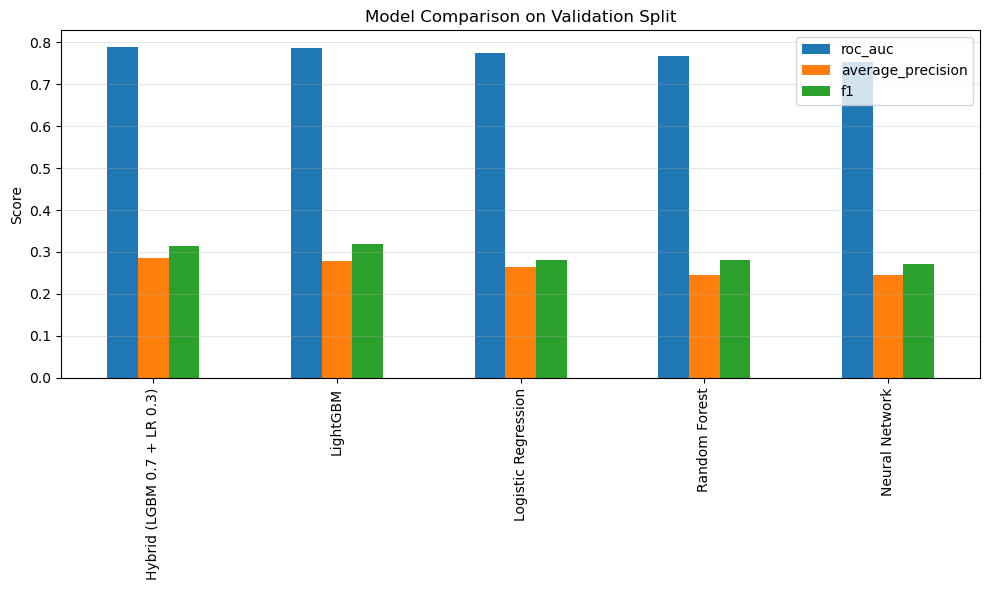

In [23]:
comparison_plot_df = results_df.set_index("model")[["roc_auc", "average_precision", "f1"]]

ax = comparison_plot_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Model Comparison on Validation Split")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

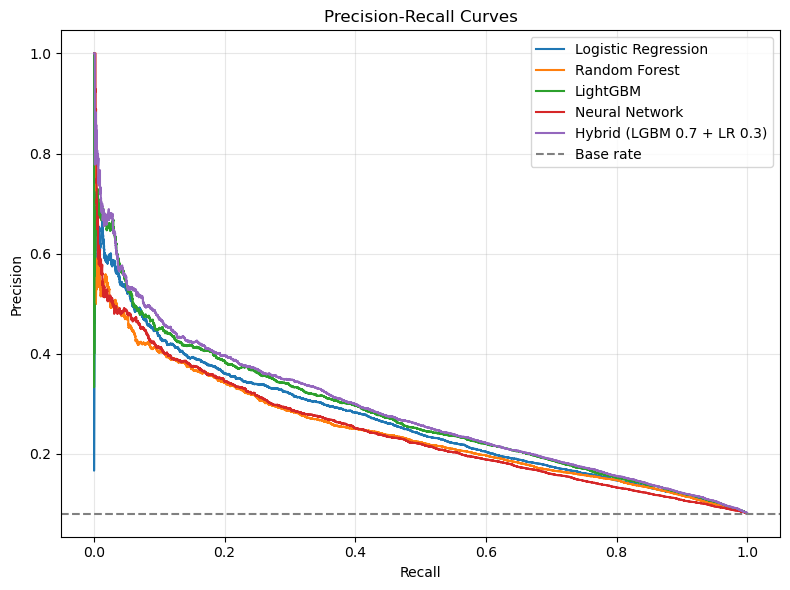

In [24]:
curve_dfs = {
    "Logistic Regression": build_precision_recall_curve_df(y_val_linear, log_reg_probs),
    "Random Forest": build_precision_recall_curve_df(y_val_tree, rf_probs),
    "LightGBM": build_precision_recall_curve_df(y_val_lgbm, lgbm_probs),
    "Neural Network": build_precision_recall_curve_df(y_val_mlp, mlp_probs),
    hybrid_results["model"]: build_precision_recall_curve_df(hybrid_y_val, hybrid_probs),
}

plt.figure(figsize=(8, 6))
for model_name, curve_df in curve_dfs.items():
    plt.plot(curve_df["recall"], curve_df["precision"], label=model_name)

baseline_precision = y_val_lgbm.mean()
plt.axhline(baseline_precision, linestyle="--", color="gray", label="Base rate")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "precision_recall_curves.png", dpi=200, bbox_inches="tight")
plt.show()

In [25]:
lgbm_threshold_table = build_threshold_table(y_val_lgbm, lgbm_probs)
log_reg_threshold_table = build_threshold_table(y_val_linear, log_reg_probs)
hybrid_threshold_table = build_threshold_table(hybrid_y_val, hybrid_probs)

pd.concat(
    [
        lgbm_threshold_table.assign(model="LightGBM"),
        log_reg_threshold_table.assign(model="Logistic Regression"),
        hybrid_threshold_table.assign(model=hybrid_results["model"]),
    ],
    ignore_index=True,
).loc[:, ["model", "threshold", "precision", "recall", "f1", "roc_auc", "average_precision"]]

,model,threshold,precision,recall,f1,roc_auc,average_precision
0,LightGBM,0.05,0.085651,0.994159,0.157715,0.785393,0.277521
1,LightGBM,0.10,0.096183,0.968983,0.174996,0.785393,0.277521
2,LightGBM,0.15,0.108373,0.938771,0.194314,0.785393,0.277521
3,LightGBM,0.20,0.121120,0.903122,0.213595,0.785393,0.277521
4,LightGBM,0.25,0.134843,0.864653,0.233303,0.785393,0.277521
5,LightGBM,0.30,0.147858,0.815911,0.250348,0.785393,0.277521
6,LightGBM,0.35,0.162664,0.769386,0.268551,0.785393,0.277521
7,LightGBM,0.40,0.179526,0.721249,0.287492,0.785393,0.277521
8,LightGBM,0.45,0.197780,0.671098,0.305520,0.785393,0.277521
9,LightGBM,0.50,0.217219,0.608258,0.320119,0.785393,0.277521


In [26]:
pd.DataFrame([
    find_threshold_for_target_precision(y_val_lgbm, lgbm_probs, target_precision=0.30),
    find_threshold_for_target_precision(hybrid_y_val, hybrid_probs, target_precision=0.30),
], index=["LightGBM", hybrid_results["model"]])

,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
LightGBM,0.7,0.891615,0.326038,0.321047,0.323523,0.785393,0.277521
Hybrid (LGBM 0.7 + LR 0.3),0.7,0.891160,0.331185,0.341591,0.336308,0.788710,0.284761


## Short Conclusions

- Treat LightGBM as the main nonlinear model unless a rerun clearly changes the ranking.
- Use Logistic Regression as the strongest simple interpretable baseline.
- Report the hybrid model as the novel contribution and compare it directly against standalone LightGBM and Logistic Regression.
- Use the tuned-threshold table when discussing F1, and use the default-threshold table when discussing ranking metrics such as ROC-AUC and average precision.